<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **U3 Clase 18**


#### **Objetivo**

El objetivo de esta clase es aprender a utilizar la Privacidad Diferencial para proteger datos con Python.

Cuando publicamos datos existe el riesgo de identificar a individuos aunque estén anonimizados. En esta clase aprenderemos a:

1. Detectar variables sensibles que permiten identificar a una persona
2. Anonimizar identificadores directos como el ID
3. Aplicar Privacidad Diferencial técnica que agrega ruido controlado para proteger la privacidad sin perder utilidad analítica


#### **Actividad 18**

Obtenga el siguiente dataframe “Adult income dataset” de https://www.kaggle.com/datasets/wenruliu/adult-income-dataset 

Resuelva lo pedido a continuación

* Evalúe riesgo de identificación a partir de combinar ‘race', 'gender','age’ 

* Aplique Privacidad Diferencial a la variable age

In [1]:
# librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import warnings
warnings.filterwarnings('ignore')

#### **1. Obtención de datos**

El dataset **Adult Income** contiene datos del censo de EEUU de 1994.

El objetivo es predecir si una persona gana más o menos de $50.000 al año.Cada fila representa una persona con sus características socioeconómicas.


In [2]:
# descargamos el dataset desde Kaggle
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\romin\.cache\kagglehub\datasets\wenruliu\adult-income-dataset\versions\2


In [3]:
# leemos el archivo CSV y guardamos en DATA
DATA=pd.read_csv(r"C:\Users\romin\.cache\kagglehub\datasets/wenruliu/adult-income-dataset/versions/2/adult.csv")
DATA.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
DATA.shape

(48842, 15)

In [5]:
DATA.columns    # nombres de todas las columnas del dataset

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='str')

#### **2. Conteo combinado para la reidentificación indirecta**

Aunque ninguna variable por si sola identifique a una persona, la combinacion de varias variables puede hacerlo.

Aqui combinamos `race`, `gender` y `age` para detectar cuantos individuos son unicos en esa combinacion.


In [6]:
# agrupamos por raza, genero y edad para ver cuantos casos hay en cada combinacion
DATA.groupby(['race', 'gender','age']).agg('count')

workclass  fnlwgt  education  educational-num  \
race               gender age                                                  
Amer-Indian-Eskimo Female 17           4       4          4                4   
                          18           4       4          4                4   
                          19           7       7          7                7   
                          20           5       5          5                5   
                          21           4       4          4                4   
...                                  ...     ...        ...              ...   
White              Male   85           3       3          3                3   
                          87           2       2          2                2   
                          88           5       5          5                5   
                          89           2       2          2                2   
                          90          30      30         30               30   

                               marital-status  occupation  relationship  \
race               gender age                                             
Amer-Indian-Eskimo Female 17                4           4             4   
                          18                4           4             4   
                          19                7           7             7   
                          20                5           5             5   
                          21                4           4             4   
...                                       ...         ...           ...   
White              Male   85                3           3             3   
                          87                2           2             2   
                          88                5           5             5   
                          89                2           2             2   
                          90               30          30            30   

                               capital-gain  capital-loss  hours-per-week  \
race               gender age                                               
Amer-Indian-Eskimo Female 17              4             4               4   
                          18              4             4               4   
                          19              7             7               7   
                          20              5             5               5   
                          21              4             4               4   
...                                     ...           ...             ...   
White              Male   85              3             3               3   
                          87              2             2               2   
                          88              5             5               5   
                          89              2             2               2   
                          90             30            30              30   

                               native-country  income  
race               gender age                          
Amer-Indian-Eskimo Female 17                4       4  
                          18                4       4  
                          19                7       7  
                          20                5       5  
                          21                4       4  
...                                       ...     ...  
White              Male   85                3       3  
                          87                2       2  
                          88                5       5  
                          89                2       2  
                          90               30      30  

[575 rows x 12 columns]

In [7]:
# agrupamos y contamos casos unicos por combinacion de race, gender y age
# as_index=False para obtenrr un df
data_1 = DATA.groupby(['race', 'gender','age'], as_index=False).workclass.count()

In [8]:
# cada fila es una combinacion unica: la columna workclass indica cuantos casos tiene
data_1    

,race,gender,age,workclass
0,Amer-Indian-Eskimo,Female,17,4
1,Amer-Indian-Eskimo,Female,18,4
2,Amer-Indian-Eskimo,Female,19,7
3,Amer-Indian-Eskimo,Female,20,5
4,Amer-Indian-Eskimo,Female,21,4
...,...,...,...,...
570,White,Male,85,3
571,White,Male,87,2
572,White,Male,88,5
573,White,Male,89,2


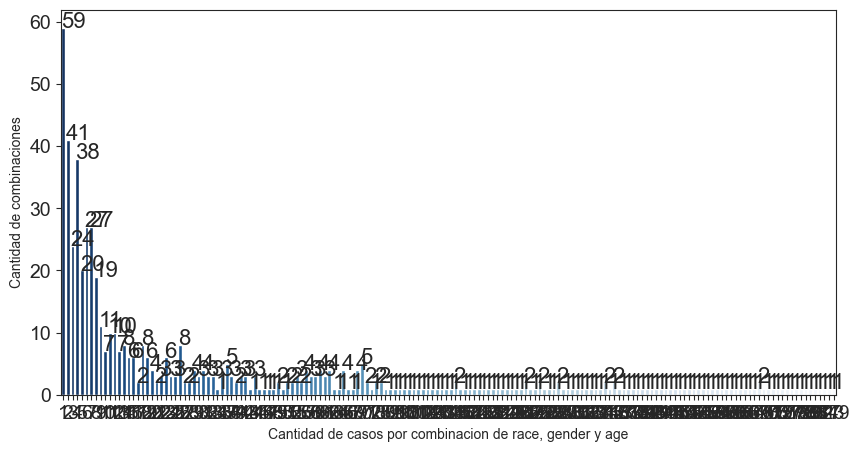

In [9]:
import seaborn as sns
from matplotlib import pyplot as plt

# visualizamos cuantas combinaciones tienen 1, 2, 3... casos
# las barras con valor 1 son las combinaciones unicas => riesgo de identificacion
sns.set_style("ticks")
plt.figure(figsize=(10, 5))

# countplot cuenta cuantos registros hay en cada valor de 'workclass' y dibuja una barra por cada uno
# el resultado se guarda en 'a'
a = sns.countplot(x='workclass', data=data_1, palette="Blues_r")
a.tick_params(labelsize=14)

# agrega el valor numerico encima de cada barra
for p in a.patches:
    a.annotate('{:.0f}'.format(p.get_height()), (p.get_x(), p.get_height()), fontsize=16)

plt.xlabel("Cantidad de casos por combinacion de race, gender y age")
plt.ylabel("Cantidad de combinaciones")
plt.show()

In [10]:
# calculo cuantos casos
casos_unicos = data_1[data_1['workclass'] == 1].shape[0]
casos_unicos

59

#### **3. Aplicacion de Privacidad Diferencial**

La Privacidad Diferencial agrega ruido aleatorio controlado a los datos para proteger la privacidad.

El parametro epsilon (e) controla el balance entre privacidad y precision:
- **e pequeño** → mas ruido → mas privacidad → menos precision
- **e grande**  → menos ruido → menos privacidad → mas precision


In [37]:
# instalamos la libreria OpenDP para privacidad diferencial
# !pip install opendp

In [11]:
import opendp    # cargamos la libreria

In [12]:
#se genera una copia del conjunto de datos
individuos_3 = DATA.copy()

In [13]:
# se observa
individuos_3    

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


* ¿Por qué age y no otra variable?

El mecanismo de Laplace agrega ruido numérico.  

`age` es numérica y continua: tiene muchos valores distintos lo que la hace una variable sensible para re-identificación.

Además el ruido numérico que agrega Laplace tiene sentido sobre una edad (sumar ±1 o ±2 años no distorsiona considerablemente el análisis)


In [14]:
# valores unicos de la variable age: sobre la cual aplicaremos privacidad diferencial
pd.unique(individuos_3['age'])

array([25, 38, 28, 44, 18, 34, 29, 63, 24, 55, 65, 36, 26, 58, 48, 43, 20,
       37, 40, 72, 45, 22, 23, 54, 32, 46, 56, 17, 39, 52, 21, 42, 33, 30,
       47, 41, 19, 69, 50, 31, 59, 49, 51, 27, 57, 61, 64, 79, 73, 53, 77,
       80, 62, 35, 68, 66, 75, 60, 67, 71, 70, 90, 81, 74, 78, 82, 83, 85,
       76, 84, 89, 88, 87, 86])

In [15]:
individuos_3['age'].min()    # edad minima del dataset

np.int64(17)

In [16]:
individuos_3['age'].max()    # edad maxima del dataset

np.int64(90)

In [17]:
# contamos cuantos registros hay por cada edad
individuos_3.groupby(['age'])['age'].agg('count')

age
17     595
18     862
19    1053
20    1113
21    1096
      ... 
86       1
87       3
88       6
89       2
90      55
Name: age, Length: 74, dtype: int64

In [18]:
# visualizar la distribucion de edades por rangos
cp_categorias = ['<= 40', '41-60', '61-80', '81-90']  # etiqueta del rango
cut_bins = [-1, 40, 60, 80, 90]                       # limites de cada intervalo : (límite_inferior, límite_superior]

# pd.cut() divide la edad continua en intervalos y les asigna una etiqueta
individuos_3['age_2'] = pd.cut(individuos_3['age'], bins=cut_bins, labels=cp_categorias)

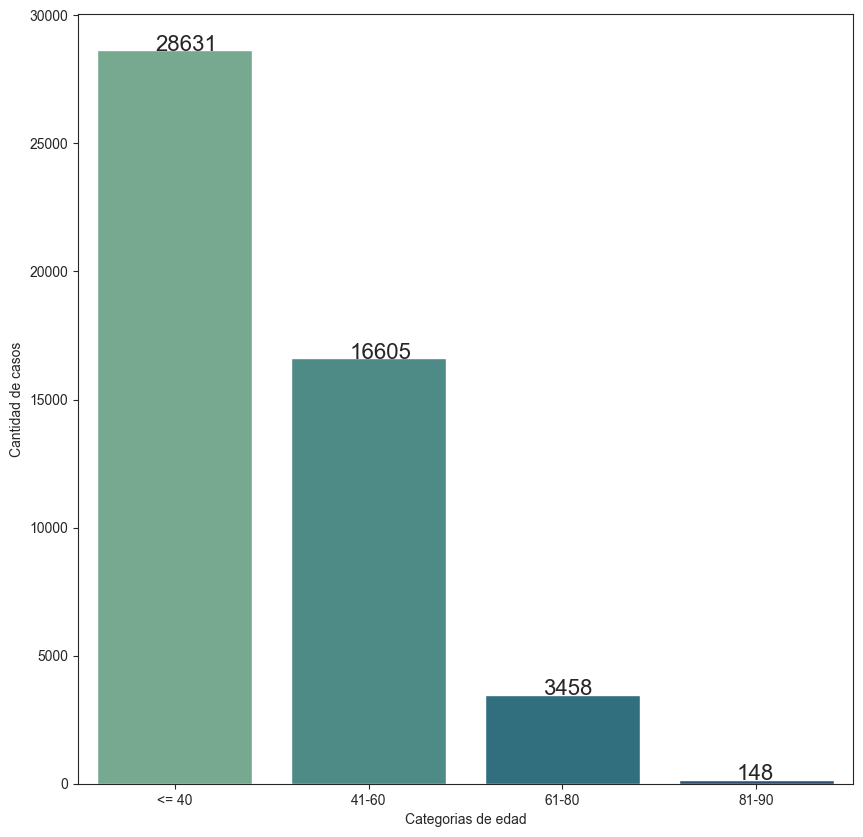

In [19]:
# visualizamos la distribucion de edad recategorizada

plt.figure(figsize=(10, 10))
m = sns.countplot(x="age_2", data=individuos_3, palette="crest")

for p in m.patches:
    m.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + 0.3, p.get_height()), fontsize=16)
    
plt.ylabel("Cantidad de casos")
plt.xlabel("Categorias de edad")
plt.show()

##### 3.1 Generación de muestra y aplicacion de Privacidad Diferencial

Vamos a aplicar Privacidad Diferencial usando el mecanismo de Laplace sobre un histograma.

* ¿Qué es el método del histograma? 

En vez de exponer los datos de cada persona, agrupa la variable en intervalos,cuenta cuántas personas hay en cada categoría (por ejemplo, cuántas tienen menos de 40 años, cuántas entre 41 y 60, etc.) y agregamos ruido a esos conteos.

Así se publican estadísticas generales útiles para analizar tendencias, pero se protege la identidad de las personas individuales.

In [21]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
# generamos una muestra aleatoria de 1000 registros
# y guardamos como CSV porq OpenDP no trabaja con df
sample_size = 1000
sample = individuos_3.sample(n=sample_size, random_state=np.random.seed(2024))
sample.to_csv("samplefile.csv", index=False, header=False)    

In [21]:
# verificamos dimensiones de la muestra
sample.shape    

(1000, 16)

In [22]:
# nombres de columnas de la muestra
sample.columns    

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'age_2'],
      dtype='str')

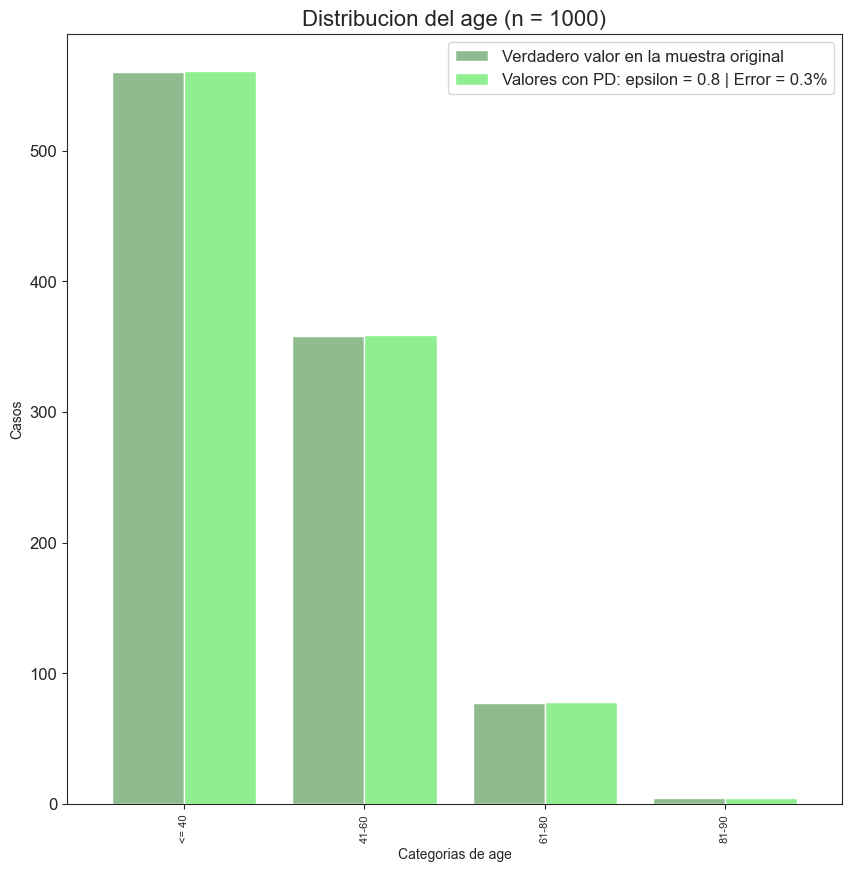

In [23]:
# nombre de las columnas del CSV : OpenDP necesita saber la estructura del archivo
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'educational_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'age_2']

categories = ['<= 40', '41-60', '61-80', '81-90']

import opendp.prelude as dp
# definimos la estructura para aplicar 
dp.enable_features("contrib", "floating-point")  # habilitamos 2 funcionalidades necesarias (conteo por cat. y num. flot)
max_influence = 1                                # cada individuo puede estar en 1 sola categoria
budget = (0.8, 1e-8)                             # epsilon=0.8 → nivel de privacidad (cuanto menor, mas privacidad)

# leemos el CSV
with open('samplefile.csv') as input_data:
    data_csv = input_data.read()

# pipeline SIN ruido: lee el CSV → selecciona age_2  → cuenta por categoria
histogram = (
    dp.t.make_split_dataframe(separator=",", col_names=col_names) >> 
    dp.t.make_select_column(key="age_2", TOA=str) >>
    dp.t.then_count_by_categories(categories=categories)
)

# pipeline CON ruido: busca automaticamente la escala de Laplace que cumple con epsilon=0.8
noisy_histogram = dp.binary_search_chain(
    lambda s: histogram >> dp.m.then_laplace(scale=s),
    d_in=max_influence,
    d_out=budget[0]
)

# conteo REAL sin ruido
sensitive_counts = histogram(data_csv)     


# conteo CON ruido de Laplace
np.random.seed(2024)
released_counts = noisy_histogram(data_csv) 

# combinamos ambos conteos en un DataFrame para comparar
sens_rele = pd.DataFrame({'sensitive_counts': sensitive_counts, 'released_counts': released_counts})
sens_rele = sens_rele[:-1]  # OpenDP agrega una fila extra al final —> la eliminamos

# calculamos el error: diferencia promedio entre conteo real y conteo con ruido en %
def perc_error(true_col, dp_col):
    error = sum(abs(true_col - dp_col)) / sum(true_col) * 100
    return error

# aplicamos la funcion para calcular el error entre el conteo real y el conteo con ruido
error = perc_error(sens_rele['sensitive_counts'], sens_rele['released_counts'])

# leyenda del grafico: muestra epsilon y el error calculado
labels = ['Verdadero valor en la muestra original']
labels.append('Valores con PD: epsilon = ' + str(budget[0]) + ' | Error = ' + str(round(error, 1)) + '%')

# grafico de barras comparativo: verde oscuro=real | verde claro=con ruido
colors = ['darkseagreen', 'lightgreen']
bar1 = sens_rele.plot.bar( figsize=(10, 10), width=0.8, fontsize=12, color=colors)
plt.legend(fontsize=12, labels=labels)
plt.title('Distribucion del age (n = ' + str(sens_rele['sensitive_counts'].sum()) + ')', fontsize=16)
plt.xticks(np.arange(len(categories)), categories, rotation=90, fontsize=8)
plt.xlabel('Categorias de age')
plt.ylabel('Casos')
plt.show()

* Los conteos obtenidos son parecidos a los valores reales, pero presentan pequeñas diferencias debido al ruido agregado. Ese ruido ayuda a proteger la privacidad de las personas sin afectar demasiado la utilidad general de la información.

### 3.2 — Evaluacion para distintos tamaños de muestra y valores de epsilon

Evaluamos el error que introduce la privacidad diferencial para distintos valores de epsilon y tamaños de muestra:
- A menor epsilon → mas ruido → mayor error → mas privacidad
- A mayor tamaño de muestra → menor error a igual epsilon


In [ ]:
def evaulacion(datos, sample_sizes, epsilons, categories, name_key):
    """
    Evalua el error de privacidad diferencial para distintos tamaños de muestra y epsilons.
    Genera un grafico comparativo por cada tamaño de muestra.
    
    Parametros:
        datos        → DataFrame con los datos
        sample_sizes → lista de tamanos de muestra a evaluar
        epsilons     → lista de valores de epsilon a evaluar
        categories   → categorias de la variable
        name_key     → nombre de la columna categorizada
    """
    for sample_size in sample_sizes:                # recorremos cada tamano de muestra
        # generamos la muestra y la guardamos como CSV
        sample = datos.sample(n=sample_size, random_state=np.random.seed(2024))
        sample.to_csv('samplefile.csv', index=False, header=False)

        col_names = ['age', 'workclass', 'fnlwgt', 'education', 'educational_num',
                     'marital_status', 'occupation', 'relationship', 'race', 'gender',
                     'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
                     'income', 'age_2']

        # leemos el CSV como texto
        with open('samplefile.csv') as input_data:
            data = input_data.read()

        import opendp.prelude as dp
        dp.enable_features("contrib", "floating-point")
        max_influence = 1

        # pipeline SIN ruido: base de comparación
        histogram = (
            dp.t.make_split_dataframe(separator=",", col_names=col_names) >>
            dp.t.make_select_column(key=name_key, TOA=str) >>
            dp.t.then_count_by_categories(categories=categories)
        )
        # conteo REAL sin ruido
        sensitive_counts = histogram(data)                      
        sens_rele = pd.DataFrame({'sensitive_counts': sensitive_counts})
        labels = ['Verdadero valor en la muestra original']

        # recorremos cada epsilon y agregamos su conteo con ruido al DataFrame
        for epsilon in epsilons:
            budget = (epsilon, 1e-8)

            # pipeline CON ruido para este epsilon
            noisy_histogram = dp.binary_search_chain(
                lambda s: histogram >> dp.m.then_laplace(scale=s),
                d_in=max_influence,
                d_out=budget[0]
            )

            np.random.seed(2024)
            released_counts = noisy_histogram(data)             # conteo CON ruido
            sens_rele['Laplace-PD-' + str(epsilon)] = released_counts

            # calculamos el error en %
            def perc_error(true_col, dp_col):
                error = sum(abs(true_col - dp_col)) / sum(true_col) * 100
                return error

            error = perc_error(sens_rele['sensitive_counts'], sens_rele['Laplace-PD-' + str(epsilon)])

            # agregamos la etiqueta para la leyenda
            labels.append('Valores con PD: epsilon = ' + str(budget[0]) + ' | Error = ' + str(round(error, 1)) + '%')

        # grafico comparativo: una barra por cada epsilon mas la barra del conteo real
        sens_rele = sens_rele[:-1]   # OpenDP agrega una fila extra — la eliminamos
        colors = ['darkseagreen', 'lightgreen', 'mediumseagreen', 'limegreen', 'green']
        bar1 = sens_rele.plot.bar(rot=45, figsize=(10, 10), width=0.8, fontsize=12, color=colors)
        plt.legend(fontsize=12, labels=labels)
        plt.title('Distribucion del age (n = ' + str(sens_rele['sensitive_counts'].sum()) + ')', fontsize=16)
        plt.xticks(np.arange(len(categories)), categories, rotation=90, fontsize=8)
        plt.xlabel('Categorias de age')
        plt.ylabel('Casos')
    return bar1

<Axes: title={'center': 'Distribucion del age (n = 48842)'}, xlabel='Categorias de age', ylabel='Casos'>

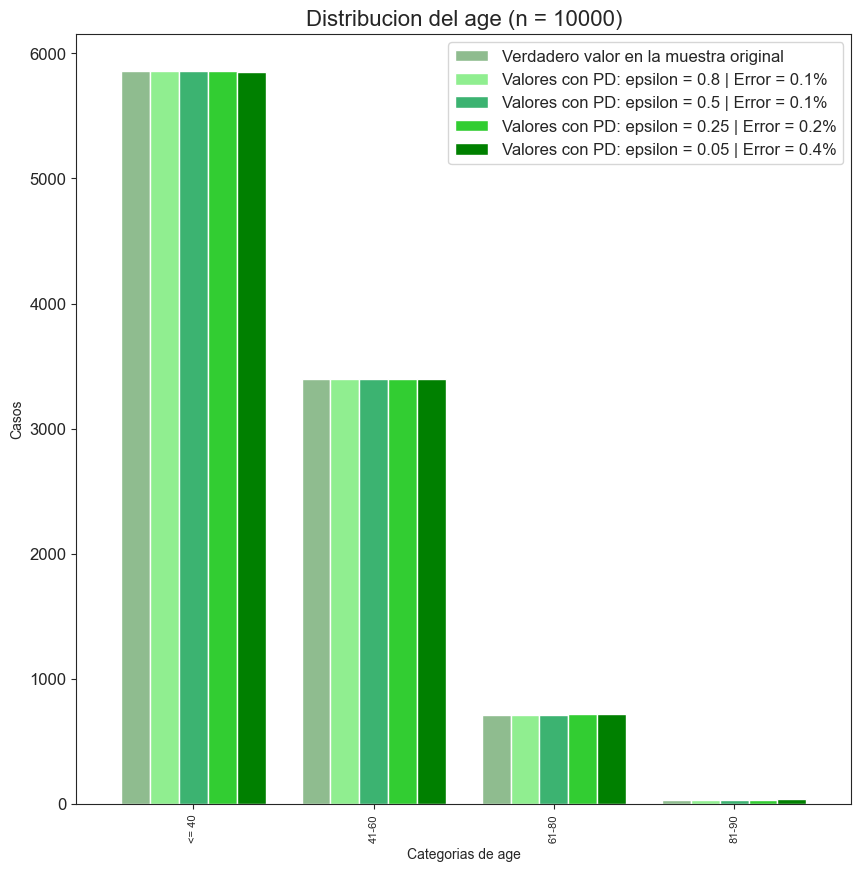

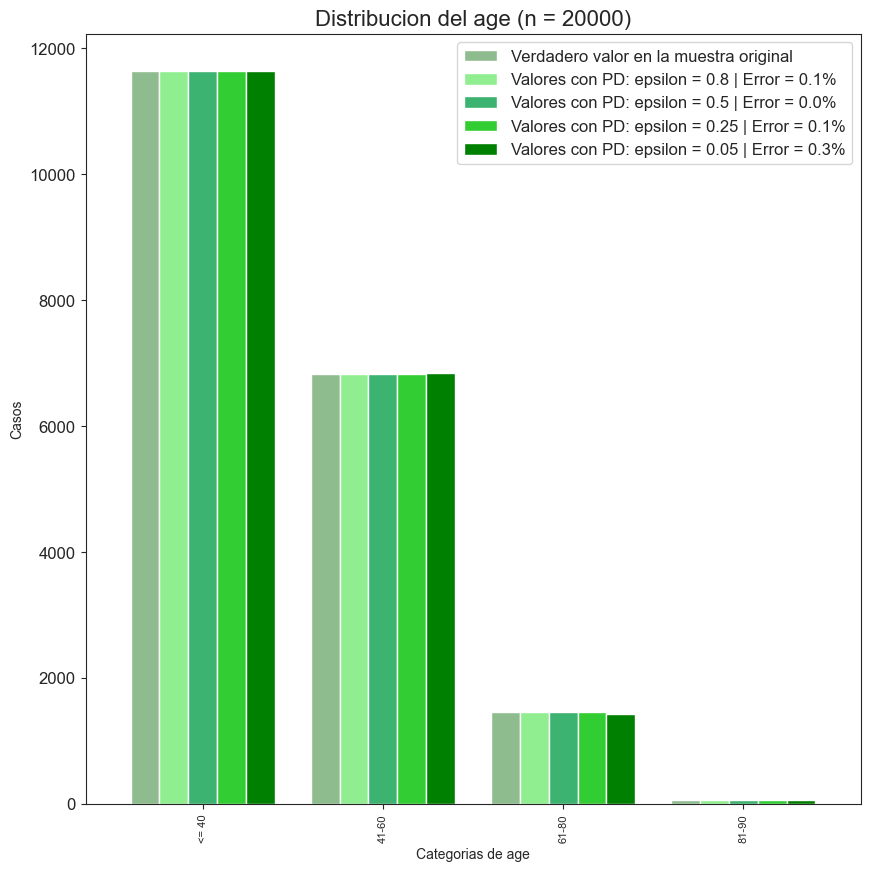

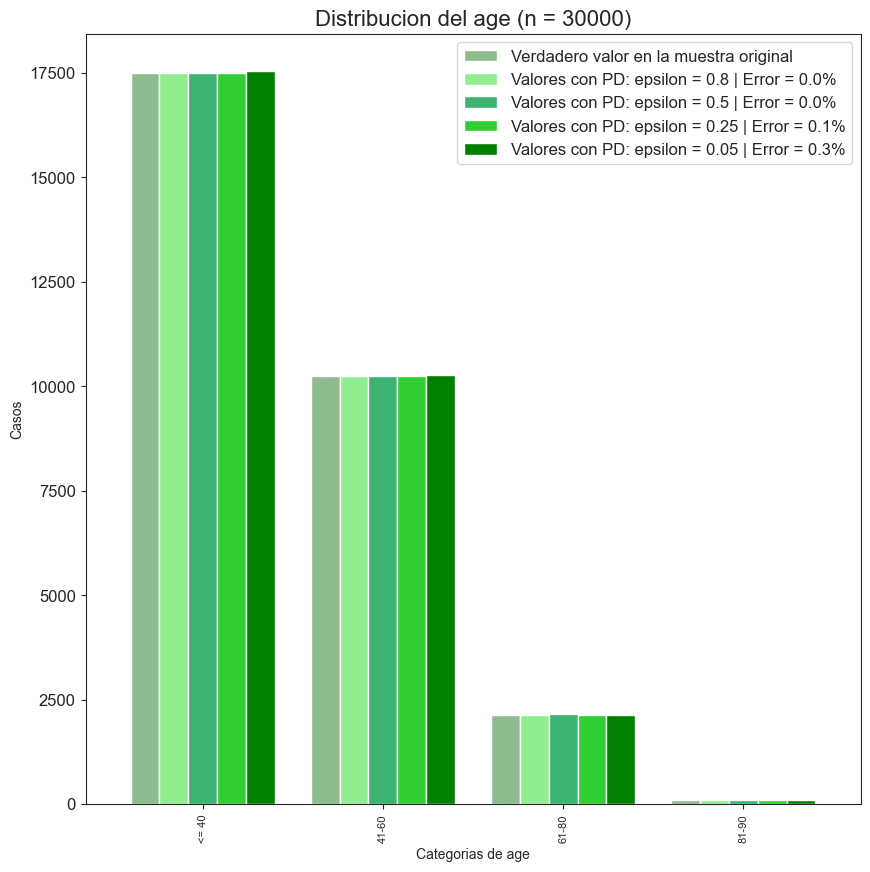

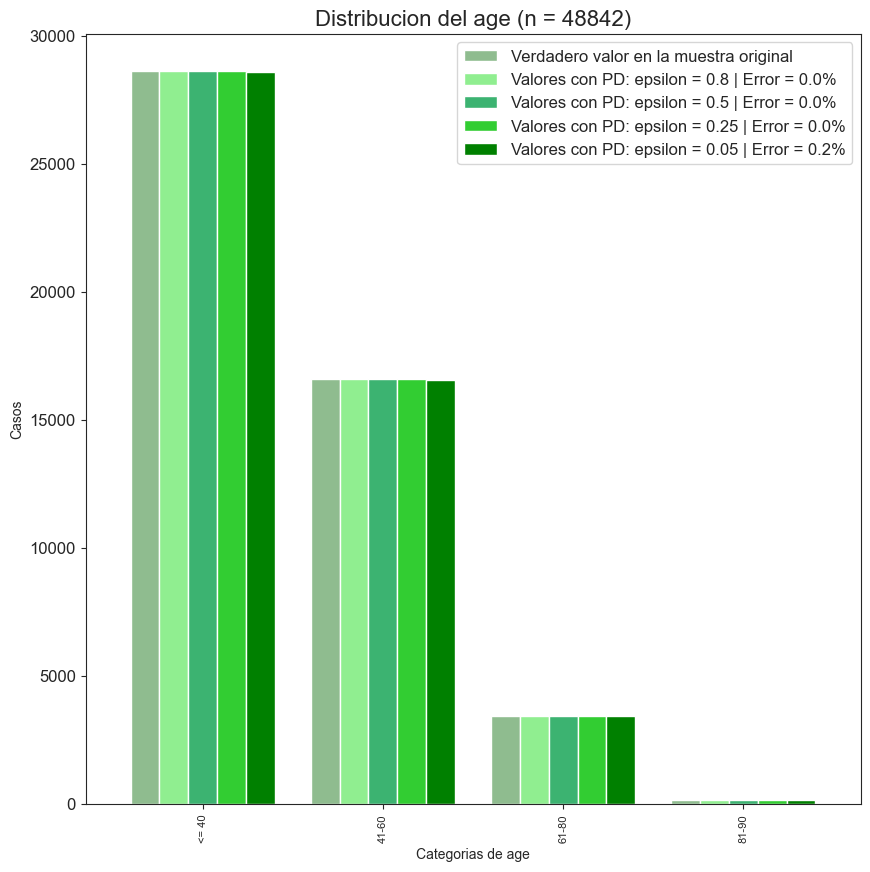

In [28]:
# aplicamos la funcion con distintos tamanos de muestra y valores de epsilon
# para cada combinacion vemos como cambia el error
evaulacion(individuos_3,
           [10000, 20000, 30000, 48842],            # tamanos de muestra a evaluar
           [0.8, 0.5, 0.25, 0.05],                  # valores de epsilon a evaluar
           ['<= 40', '41-60', '61-80', '81-90'],    # categorias de la variable
           'age_2')                                 # nombre de la columna categorizada


* En general, a medida que disminuye el valor de epsilon, el error tiende a aumentar, lo cual es esperable, ya que un menor epsilon implica mayor privacidad y, por lo tanto, mayor cantidad de ruido agregado.

* No obstante, los errores obtenidos son bajos en todos los escenarios, lo que evidencia que la privacidad diferencial mediante el mecanismo de Laplace conserva la utilidad general de los datos agregados.

## **4. Implementacion de ruido aleatorio y evaluacion de resultados**

### 4.1. Aplicacion de ruido a la variable age

Vamos a agregar ruido directamente a cada valor individual de `age`. Esto se usa cuando necesitamos publicar los valores individuales (no conteos agregados).

Usamos el epsilon elegido en la evaluación anterior.


In [29]:
#se define una función que aplica ruido aletorio según mecanismo de Lapalce

def ruido(data, variable, variable_new, sensitivity, epsilon):
    """
    Aplica ruido aleatorio de Laplace a una variable numerica.
    A diferencia del pipeline de OpenDP que agrega ruido al CONTEO,
    esta funcion agrega ruido a cada VALOR individual de la variable.

    Parametros:
        data         → DataFrame con los datos
        variable     → nombre de la columna original
        variable_new → nombre de la nueva columna con ruido
        sensitivity  → sensibilidad de la consulta
        epsilon      → presupuesto de privacidad (a menor epsilon mas ruido)
    """
    np.random.seed(2024)   # fijamos la semilla para que el ruido sea reproducible
    # np.random.laplace(loc=0, scale=...) genera un numero aleatorio de Laplace
    # loc=0 → centrado en 0 (puede ser positivo o negativo)
    # scale=sensitivity/epsilon → controla la magnitud del ruido
    data[variable_new] = data[variable] + np.random.laplace(loc=0, scale=sensitivity/epsilon)
    return data

In [30]:
# aplicamos ruido con epsilon=0.25, elegido de la evaluacion anterior
# con este epsilon el error es bajo y la privacidad es razonable
dapar = ruido(individuos_3.copy(), 'age', 'age_2', 1, 0.25)

In [31]:
dapar    # verificamos el resultado

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,age_2
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,25.77448
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,38.77448
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,28.77448
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,44.77448
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,18.77448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,27.77448
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,40.77448
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,58.77448
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,22.77448


In [32]:
# estadisticas descriptivas de la variable age con ruido
dapar['age_2'].describe()

count    48842.000000
mean        39.418065
std         13.710510
min         17.774480
25%         28.774480
50%         37.774480
75%         48.774480
max         90.774480
Name: age_2, dtype: float64

### 4.2 — Comparacion visual: con ruido vs sin ruido

Comparamos la distribucion de la edad **con** y **sin** ruido para verificar que la privacidad diferencial no distorsiona la distribucion general.


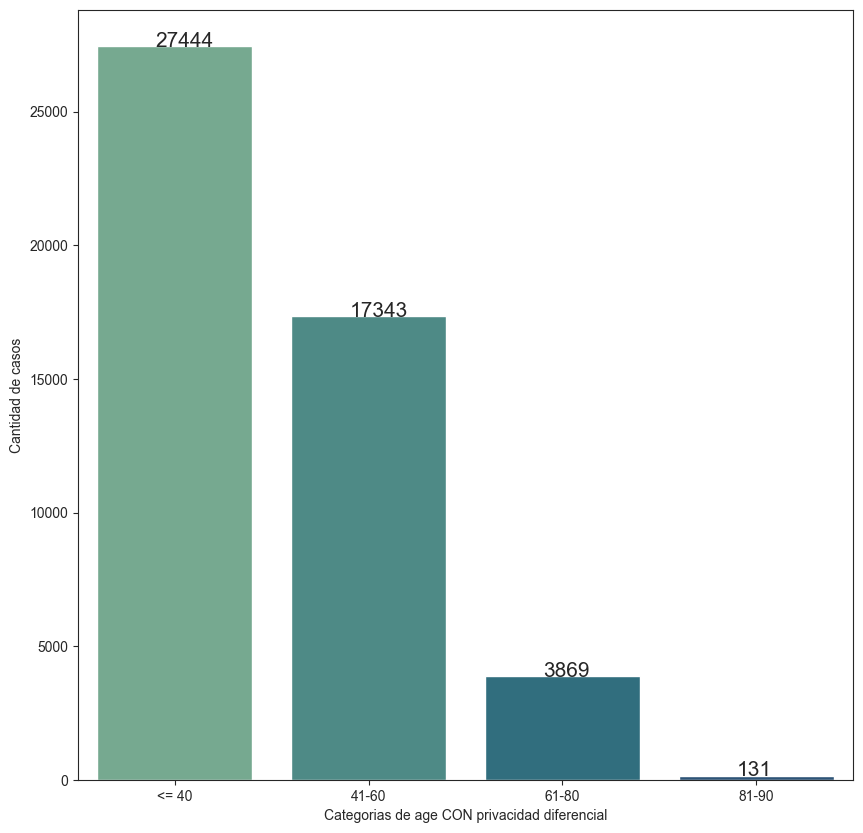

In [33]:
# recategorizamos la variable age CON ruido para visualizar la distribucion
edad_categorias_2 = ['<= 40', '41-60', '61-80', '81-90']
cut_bins_2 = [-1, 40, 60, 80, 90]
dapar['age_3'] = pd.cut(dapar['age_2'], bins=cut_bins_2, labels=edad_categorias_2)

# grafico de la distribucion CON ruido
plt.figure(figsize=(10, 10))
dp3 = sns.countplot(x="age_3", data=dapar, palette="crest")

# anotamos el valor encima de cada barra
for p in dp3.patches:
    dp3.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + 0.3, p.get_height() + 0.01), fontsize=15)

plt.ylabel("Cantidad de casos")
plt.xlabel("Categorias de age CON privacidad diferencial")
plt.show()

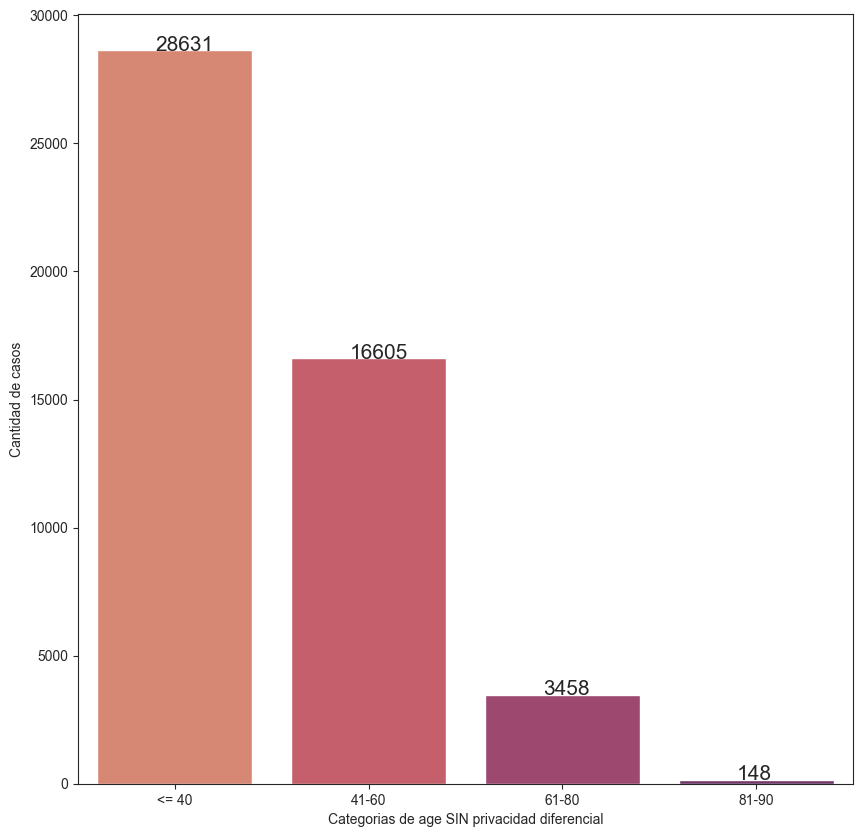

In [34]:
# recategorizamos la variable age ORIGINAL para comparar
dapar['age_4'] = pd.cut(dapar['age'], bins=cut_bins_2, labels=edad_categorias_2)

# grafico de la distribucion SIN ruido
plt.figure(figsize=(10, 10))
dp4 = sns.countplot(x="age_4", data=dapar, palette="flare")

for p in dp4.patches:
    dp4.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + 0.3, p.get_height()), fontsize=15)

plt.ylabel("Cantidad de casos")
plt.xlabel("Categorias de age SIN privacidad diferencial")
plt.show()


* Entre ambos graficos no se observa variación significativa en la distribucion de la variable edad recategorizada con y sin ruido aleatorio.

* Esto confirma que la Privacidad Diferencial protege la privacidad de los individuos sin distorsionar la distribucion general de los datos, mantieniendo la utilidad analítica.

